In [73]:

#Import Libraries


#Data manipulation
import pandas as pd
import numpy as np

#Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Machine learning models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

#XGBoost model
from xgboost import XGBRegressor

#Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Dvaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix
)

#Ignore warnings
import warnings
warnings.filterwarnings("ignore")
from imblearn.over_sampling import SMOTE

In [74]:

#Load dataset
df = pd.read_csv('/kaggle/input/datasets/ghinawaleed/floodset/train.csv')

#Select random 10,000 rows
df = df.sample(n=10000, random_state=42)

#Drop unnecessary column
df.drop("id", axis=1, inplace=True)

#Display first rows
df.head()
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1105809 to 730454
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   MonsoonIntensity                 10000 non-null  int64  
 1   TopographyDrainage               10000 non-null  int64  
 2   RiverManagement                  10000 non-null  int64  
 3   Deforestation                    10000 non-null  int64  
 4   Urbanization                     10000 non-null  int64  
 5   ClimateChange                    10000 non-null  int64  
 6   DamsQuality                      10000 non-null  int64  
 7   Siltation                        10000 non-null  int64  
 8   AgriculturalPractices            10000 non-null  int64  
 9   Encroachments                    10000 non-null  int64  
 10  IneffectiveDisasterPreparedness  10000 non-null  int64  
 11  DrainageSystems                  10000 non-null  int64  
 12  CoastalVulnerabi

MonsoonIntensity                   0
TopographyDrainage                 0
RiverManagement                    0
Deforestation                      0
Urbanization                       0
ClimateChange                      0
DamsQuality                        0
Siltation                          0
AgriculturalPractices              0
Encroachments                      0
IneffectiveDisasterPreparedness    0
DrainageSystems                    0
CoastalVulnerability               0
Landslides                         0
Watersheds                         0
DeterioratingInfrastructure        0
PopulationScore                    0
WetlandLoss                        0
InadequatePlanning                 0
PoliticalFactors                   0
FloodProbability                   0
dtype: int64

In [75]:

#Create Risk Categories


#Convert flood probability into risk levels

def classify_risk(prob):
    if prob < 0.45:
        return "Low"
    elif prob < 0.60:
        return "Medium"
    else:
        return "High"

df["RiskLevel"] = df["FloodProbability"].apply(classify_risk)

#Display class distribution
print(df["RiskLevel"].value_counts())

RiskLevel
Medium    8431
Low       1241
High       328
Name: count, dtype: int64


## Class Balance Analysis

The original dataset was imbalanced after converting the flood probability into three risk categories:

- Medium = 8431  
- Low = 1241  
- High = 328  

To address this issue and improve model fairness, SMOTE (Synthetic Minority Oversampling Technique) was applied only to the training set after splitting the data. This helped balance the classes and reduce bias toward the majority class.


In [76]:

#Features and Target Variable


#Define features
X = df.drop(["FloodProbability", "RiskLevel"], axis=1)

# Define target
y = df["RiskLevel"]

In [77]:

#Split Dataset


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

#Display shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (8000, 20)
X_test shape: (2000, 20)


In [78]:

#Balance Classes Using SMOTE


from imblearn.over_sampling import SMOTE

#Initialize SMOTE
smote = SMOTE(random_state=42)

#Apply SMOTE on training data only
X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train,
    y_train
)

#Display balanced classes
print(y_train_balanced.value_counts())

RiskLevel
Medium    6745
Low       6745
High      6745
Name: count, dtype: int64


In [79]:

#Feature Scaling


from sklearn.preprocessing import StandardScaler

#Initialize scaler
scaler = StandardScaler()

#Scale balanced training data
X_train_scaled = scaler.fit_transform(X_train_balanced)

#Scale testing data
X_test_scaled = scaler.transform(X_test)

In [80]:

#Logistic Regression Model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

#Initialize model
log_model = LogisticRegression(max_iter=1000)

#Train model
log_model.fit(X_train_scaled, y_train_balanced)

#Predictions
y_pred_log = log_model.predict(X_test_scaled)

#Evaluation metrics
log_accuracy = accuracy_score(y_test, y_pred_log)

log_precision = precision_score(
    y_test,
    y_pred_log,
    average='weighted'
)

log_recall = recall_score(
    y_test,
    y_pred_log,
    average='weighted'
)

log_f1 = f1_score(
    y_test,
    y_pred_log,
    average='weighted'
)

#Print results
print("Logistic Regression Results")
print("Accuracy:", log_accuracy)
print("Precision:", log_precision)
print("Recall:", log_recall)
print("F1-score:", log_f1)

Logistic Regression Results
Accuracy: 0.783
Precision: 0.9135933249702093
Recall: 0.783
F1-score: 0.831602572737069


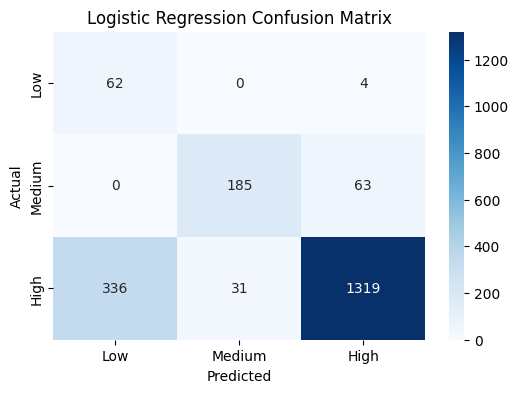

In [81]:

#Logistic Regression Confusion Matrix


import matplotlib.pyplot as plt
import seaborn as sns

#Create confusion matrix
cm = confusion_matrix(y_test, y_pred_log)

#Plot confusion matrix
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [82]:

#KNN Model


from sklearn.neighbors import KNeighborsClassifier

#Initialize model
knn_model = KNeighborsClassifier(n_neighbors=5)

#Train model
knn_model.fit(X_train_scaled, y_train_balanced)

#Predictions
y_pred_knn = knn_model.predict(X_test_scaled)

#Evaluation metrics
knn_accuracy = accuracy_score(y_test, y_pred_knn)

knn_precision = precision_score(
    y_test,
    y_pred_knn,
    average='weighted'
)

knn_recall = recall_score(
    y_test,
    y_pred_knn,
    average='weighted'
)

knn_f1 = f1_score(
    y_test,
    y_pred_knn,
    average='weighted'
)

#Print results
print("KNN Results")
print("Accuracy:", knn_accuracy)
print("Precision:", knn_precision)
print("Recall:", knn_recall)
print("F1-score:", knn_f1)

KNN Results
Accuracy: 0.641
Precision: 0.8376122128745358
Recall: 0.641
F1-score: 0.7059074339963902


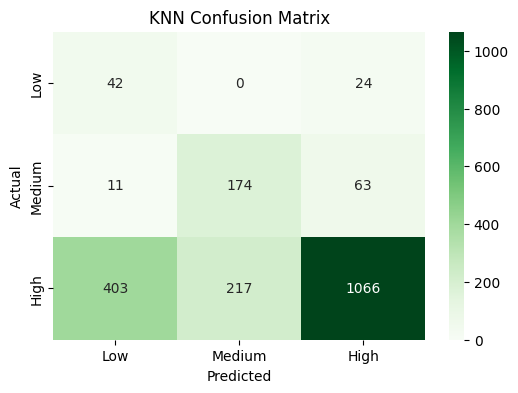

In [83]:

#KNN Confusion Matrix


#Create confusion matrix
cm = confusion_matrix(y_test, y_pred_knn)

#Plot confusion matrix
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("KNN Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [84]:

#Decision Tree Model


from sklearn.tree import DecisionTreeClassifier

# Initialize model
dt_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

#Train model
dt_model.fit(X_train_balanced, y_train_balanced)

#Predictions
y_pred_dt = dt_model.predict(X_test)

#Evaluation metrics
dt_accuracy = accuracy_score(y_test, y_pred_dt)

dt_precision = precision_score(
    y_test,
    y_pred_dt,
    average='weighted'
)

dt_recall = recall_score(
    y_test,
    y_pred_dt,
    average='weighted'
)

dt_f1 = f1_score(
    y_test,
    y_pred_dt,
    average='weighted'
)

#Print results
print("Decision Tree Results")
print("Accuracy:", dt_accuracy)
print("Precision:", dt_precision)
print("Recall:", dt_recall)
print("F1-score:", dt_f1)

Decision Tree Results
Accuracy: 0.623
Precision: 0.7843597502700217
Recall: 0.623
F1-score: 0.6809573686741159


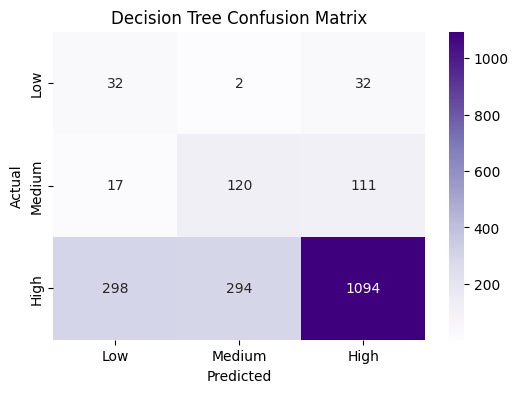

In [85]:

#Decision Tree Confusion Matrix


#Create confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)

#Plot confusion matrix
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [86]:

#Random Forest Model


from sklearn.ensemble import RandomForestClassifier

#Initialize model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

#Train model
rf_model.fit(X_train_balanced, y_train_balanced)

#Predictions
y_pred_rf = rf_model.predict(X_test)

#Evaluation metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

#Print results
print("Random Forest Results")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1-score:", rf_f1)

Random Forest Results
Accuracy: 0.8725
Precision: 0.8733118105844954
Recall: 0.8725
F1-score: 0.8635923960551367


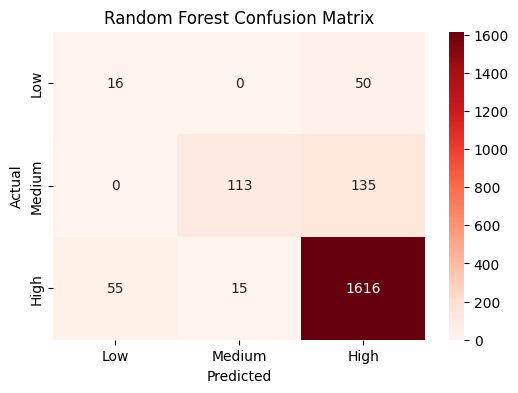

In [87]:

#Random Forest Confusion Matrix


#Create confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

#Plot confusion matrix
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

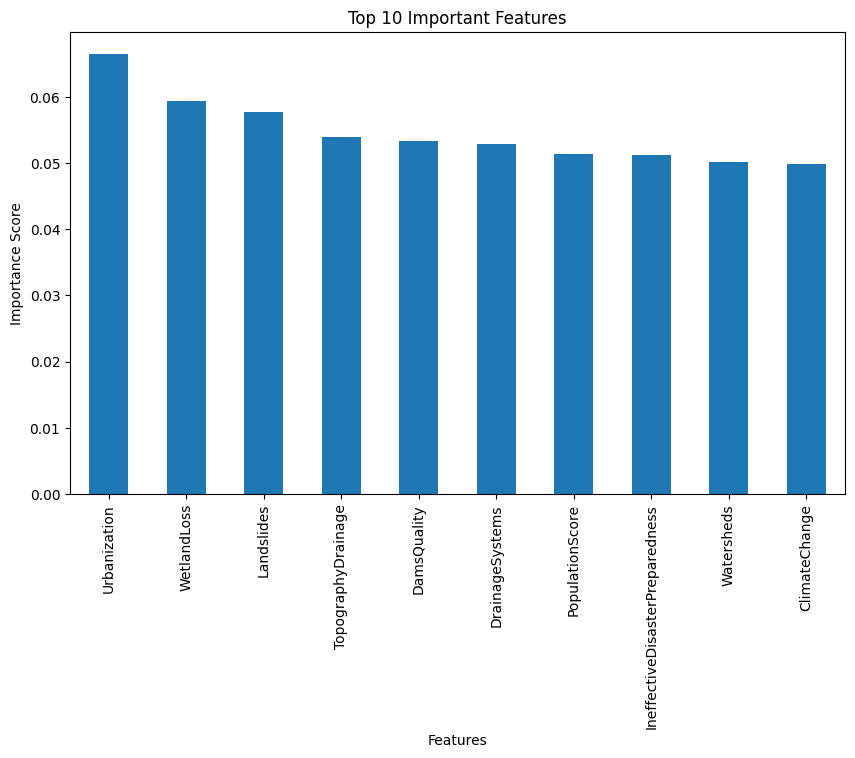

In [88]:

#Random Forest Feature Importance

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()


In [89]:

#XGBoost Model


from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

#Encode target labels
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train_balanced)
y_test_encoded = label_encoder.transform(y_test)

#Initialize model
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42,
    eval_metric='mlogloss'
)

#Train model
xgb_model.fit(X_train_balanced, y_train_encoded)

#Predictions
y_pred_xgb = xgb_model.predict(X_test)

#Evaluation metrics
xgb_accuracy = accuracy_score(y_test_encoded, y_pred_xgb)

xgb_precision = precision_score(
    y_test_encoded,
    y_pred_xgb,
    average='weighted'
)

xgb_recall = recall_score(
    y_test_encoded,
    y_pred_xgb,
    average='weighted'
)

xgb_f1 = f1_score(
    y_test_encoded,
    y_pred_xgb,
    average='weighted'
)

#Print results
print("XGBoost Results")
print("Accuracy:", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall:", xgb_recall)
print("F1-score:", xgb_f1)

XGBoost Results
Accuracy: 0.877
Precision: 0.8749061895461862
Recall: 0.877
F1-score: 0.8681926520443211


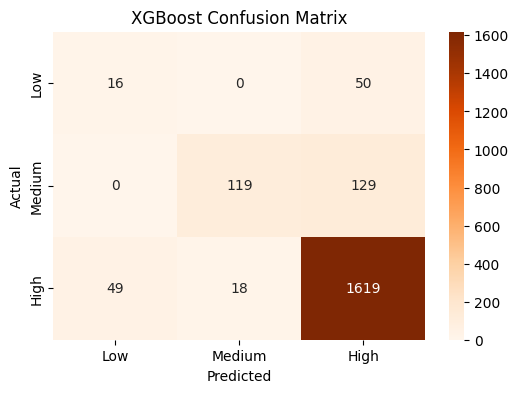

In [90]:

#XGBoost Confusion Matrix


#Create confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred_xgb)

#Plot confusion matrix
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


## Cross Validation Analysis

Cross-validation was applied to evaluate the stability and generalization ability of the models.

- 5-fold cross-validation was used.
- This technique helps ensure that the model performance is consistent across different subsets of the dataset.
- XGBoost maintained strong and stable performance during cross-validation.


In [91]:


#Cross Validation Evaluation


from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# Encode labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_balanced)

#Rebuild XGBoost model
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42
)

#Cross-validation
xgb_cv_scores = cross_val_score(
    xgb_model,
    X_train_balanced,
    y_train_encoded,
    cv=5,
    scoring='accuracy'
)

print("XGBoost CV Accuracy:", xgb_cv_scores.mean())
print("Fold Scores:", xgb_cv_scores)

XGBoost CV Accuracy: 0.9646157647640227
Fold Scores: [0.90857425 0.97949098 0.9782555  0.97899679 0.9777613 ]


In [92]:

#Models Comparison Table


results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        log_accuracy,
        knn_accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],

    "Precision": [
        log_precision,
        knn_precision,
        dt_precision,
        rf_precision,
        xgb_precision
    ],

    "Recall": [
        log_recall,
        knn_recall,
        dt_recall,
        rf_recall,
        xgb_recall
    ],

    "F1-Score": [
        log_f1,
        knn_f1,
        dt_f1,
        rf_f1,
        xgb_f1
    ]
})

#Display results table
results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7830,0.913593,0.7830,0.831603
1,KNN,0.6410,0.837612,0.6410,0.705907
2,Decision Tree,0.6230,0.784360,0.6230,0.680957
3,Random Forest,0.8725,0.873312,0.8725,0.863592
4,XGBoost,0.8770,0.874906,0.8770,0.868193


## Best Model Selection

XGBoost achieved the best overall performance among all models with the highest accuracy and F1-score.

Therefore, XGBoost was selected as the final model for the flood risk prediction system.

In [93]:

#Deep Learning Libraries


from tensorflow import keras

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout
)

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping


2026-05-23 14:40:18.935317: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779547219.161192      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779547219.223911      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779547219.789337      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779547219.789377      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779547219.789380      57 computation_placer.cc:177] computation placer alr

In [94]:

#Encode Target Labels


from sklearn.preprocessing import LabelEncoder

#Initialize encoder
label_encoder = LabelEncoder()

#Encode training labels
y_train_encoded = label_encoder.fit_transform(
    y_train_balanced
)

#Encode testing labels
y_test_encoded = label_encoder.transform(
    y_test
)

#Convert labels to categorical format
y_train_categorical = to_categorical(y_train_encoded)

y_test_categorical = to_categorical(y_test_encoded)

#Display shape
print(y_train_categorical.shape)
print(y_test_categorical.shape)

(20235, 3)
(2000, 3)


In [95]:

#Build Neural Network


#Initialize model
nn_model = Sequential()

#First hidden layer
nn_model.add(
    Dense(
        128,
        activation='relu',
        input_shape=(X_train_scaled.shape[1],)
    )
)

#Dropout layer
nn_model.add(
    Dropout(0.3)
)

#Second hidden layer
nn_model.add(
    Dense(
        64,
        activation='relu'
    )
)

#Dropout layer
nn_model.add(
    Dropout(0.3)
)

#Output layer
nn_model.add(
    Dense(
        3,
        activation='softmax'
    )
)

#Compile model
nn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#Display model summary
nn_model.summary()

2026-05-23 14:40:48.655057: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,139 (43.51 KB)

 Trainable params: 11,139 (43.51 KB)

 Non-trainable params: 0 (0.00 B)

In [96]:

#Train Neural Network


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


history = nn_model.fit(
    X_train_scaled,
    y_train_categorical,
    validation_data=(
        X_test_scaled,
        y_test_categorical
    ),
    epochs=20,
    batch_size=32
)

Epoch 1/20
633/633 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7560 - loss: 0.5393 - val_accuracy: 0.7725 - val_loss: 0.4790
Epoch 2/20
633/633 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8786 - loss: 0.2983 - val_accuracy: 0.8155 - val_loss: 0.4179
Epoch 3/20
633/633 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8869 - loss: 0.2744 - val_accuracy: 0.8285 - val_loss: 0.3800
Epoch 4/20
633/633 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9023 - loss: 0.2460 - val_accuracy: 0.8320 - val_loss: 0.3833
Epoch 5/20
633/633 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9067 - loss: 0.2338 - val_accuracy: 0.8520 - val_loss: 0.3431
Epoch 6/20
633/633 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9145 - loss: 0.2134 - val_accuracy: 0.8505 - val_loss: 0.3549
Epoch 7/20
633/633 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9203 - loss: 0.2006 - val_accuracy: 0.8410 - val_loss: 0.3523
Epoch 8/20
633/633 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9229 - loss: 0.1977 - val_accuracy: 0.

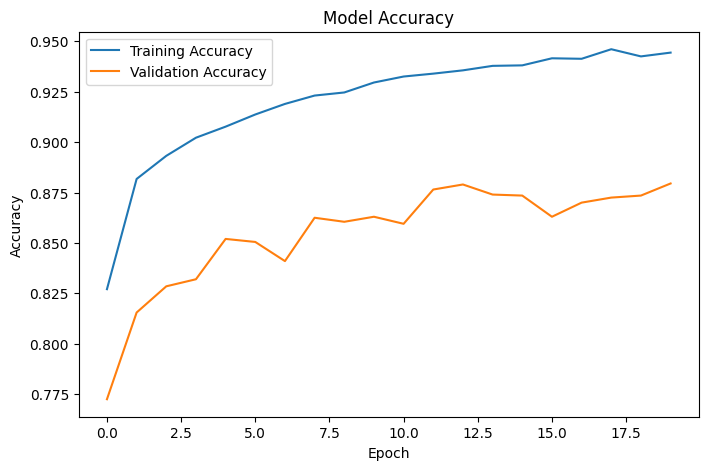

In [97]:

#Plot Accuracy Curve


plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

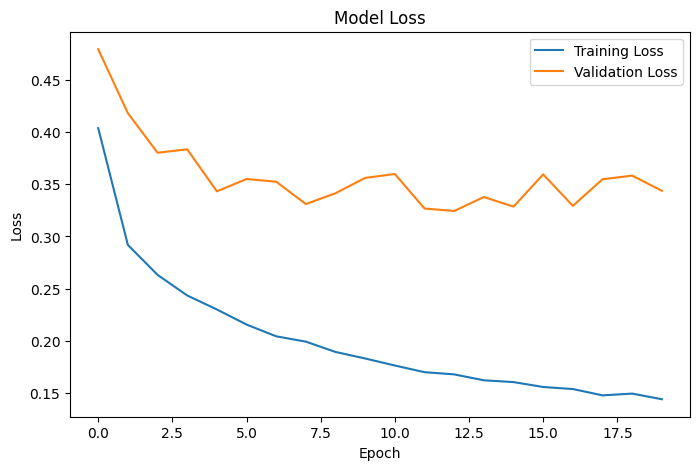

In [98]:

#Plot Loss Curve


plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend(['Training Loss', 'Validation Loss'])

plt.show()

In [99]:

#Neural Network Predictions


# Predict probabilities
y_pred_nn_prob = nn_model.predict(X_test_scaled)

# Convert probabilities to class labels
y_pred_nn = np.argmax(y_pred_nn_prob, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [100]:

#Neural Network Evaluation


#Evaluation metrics
nn_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_nn
)

nn_precision = precision_score(
    y_test_encoded,
    y_pred_nn,
    average='weighted'
)

nn_recall = recall_score(
    y_test_encoded,
    y_pred_nn,
    average='weighted'
)

nn_f1 = f1_score(
    y_test_encoded,
    y_pred_nn,
    average='weighted'
)

#Print results
print("Neural Network Results")

print("Accuracy:", nn_accuracy)

print("Precision:", nn_precision)

print("Recall:", nn_recall)

print("F1-score:", nn_f1)

Neural Network Results
Accuracy: 0.8795
Precision: 0.9086196860071831
Recall: 0.8795
F1-score: 0.8872097104090653


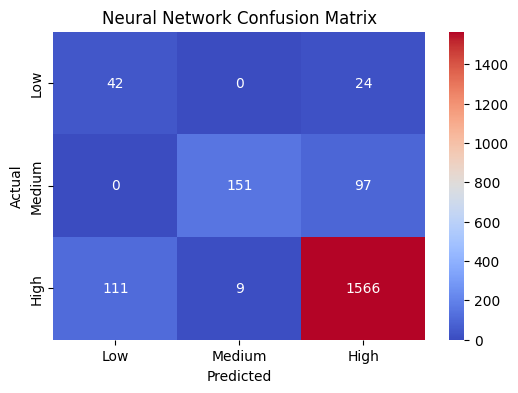

In [101]:

#Neural Network Confusion Matrix


#Create confusion matrix
cm = confusion_matrix(
    y_test_encoded,
    y_pred_nn
)

#Plot confusion matrix
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='coolwarm',
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("Neural Network Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [102]:

#Final Models Comparison


final_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Neural Network"
    ],

    "Accuracy": [
        log_accuracy,
        knn_accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy,
        nn_accuracy
    ],

    "Precision": [
        log_precision,
        knn_precision,
        dt_precision,
        rf_precision,
        xgb_precision,
        nn_precision
    ],

    "Recall": [
        log_recall,
        knn_recall,
        dt_recall,
        rf_recall,
        xgb_recall,
        nn_recall
    ],

    "F1-Score": [
        log_f1,
        knn_f1,
        dt_f1,
        rf_f1,
        xgb_f1,
        nn_f1
    ]
})

#Display comparison table
final_results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7830,0.913593,0.7830,0.831603
1,KNN,0.6410,0.837612,0.6410,0.705907
2,Decision Tree,0.6230,0.784360,0.6230,0.680957
3,Random Forest,0.8725,0.873312,0.8725,0.863592
4,XGBoost,0.8770,0.874906,0.8770,0.868193
5,Neural Network,0.8795,0.908620,0.8795,0.887210


## Final Model Selection

Neural Network achieved the best overall performance with the highest weighted F1-score and strong generalization ability.

Therefore, Neural Network was selected as the final deployed model for the flood risk prediction system because it provides stable and accurate multiclass flood risk classification.


In [ ]:

#Save Neural Network Model

nn_model.save("flood_neural_network.h5")

print("Neural Network model saved successfully!")

In [ ]:

#Save Label Encoder


import joblib

joblib.dump(label_encoder, "label_encoder.pkl")

print("Label encoder saved successfully!")

In [ ]:

#Save Scaler

joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")